In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC, SVR
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, mean_squared_error, r2_score)

%matplotlib inline

In [2]:
rng = np.random.RandomState(42)
n = 500
X = np.c_[rng.uniform(-3, 3, n), rng.uniform(-3, 8, n)]
boundary = X[:, 0] ** 2 - 2
noise = rng.normal(0, 0.6, n)
y = (X[:, 1] + noise > boundary).astype(int)
data = pd.DataFrame(X, columns=['x1', 'x2'])
data['label'] = y
print(data.shape)
data.head() 

(500, 3)


,x1,x2,label
0,-0.752759,4.679779,1
1,2.704286,2.897060,0
2,1.391964,0.404804,1
3,0.591951,5.951745,1
4,-2.063888,4.532043,1


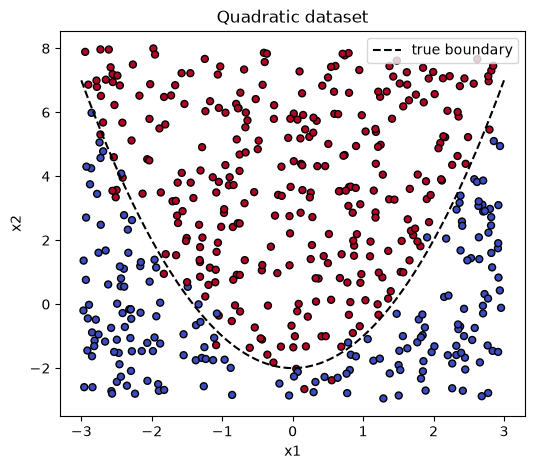

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=25)
xs = np.linspace(-3, 3, 200)
plt.plot(xs, xs**2 - 2, 'k--', label='true boundary')
plt.xlabel('x1'); plt.ylabel('x2'); plt.legend()
plt.title('Quadratic dataset')
plt.show() 

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=5, stratify=y)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

sc = StandardScaler()
x_train_s = sc.fit_transform(x_train)
x_test_s = sc.transform(x_test) 

(350, 2) (350,) (150, 2) (150,)


In [5]:
models = {
    'linear': SVC(kernel='linear', random_state=0),
    'poly (deg=2)': SVC(kernel='poly', degree=2, coef0=1, C=1, random_state=0),
    'rbf': SVC(kernel='rbf', random_state=0),
}

fitted = {}
for name, m in models.items():
    m.fit(x_train_s, y_train)
    pred = m.predict(x_test_s)
    fitted[name] = m
    print(f'SVC [kernel - {name}]')
    print('Confusion Matrix:\n', confusion_matrix(y_test, pred))
    print('Accuracy:', round(accuracy_score(y_test, pred), 4))
    print(classification_report(y_test, pred))
    print('-' * 60) 

SVC [kernel - linear]
Confusion Matrix:
 [[41 17]
 [12 80]]
Accuracy: 0.8067
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        58
           1       0.82      0.87      0.85        92

    accuracy                           0.81       150
   macro avg       0.80      0.79      0.79       150
weighted avg       0.80      0.81      0.80       150

------------------------------------------------------------
SVC [kernel - poly (deg=2)]
Confusion Matrix:
 [[54  4]
 [ 2 90]]
Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.96      0.93      0.95        58
           1       0.96      0.98      0.97        92

    accuracy                           0.96       150
   macro avg       0.96      0.95      0.96       150
weighted avg       0.96      0.96      0.96       150

------------------------------------------------------------
SVC [kernel - rbf]
Confusion Matrix:
 [[53  5]
 [ 2 90]]
Accuracy:

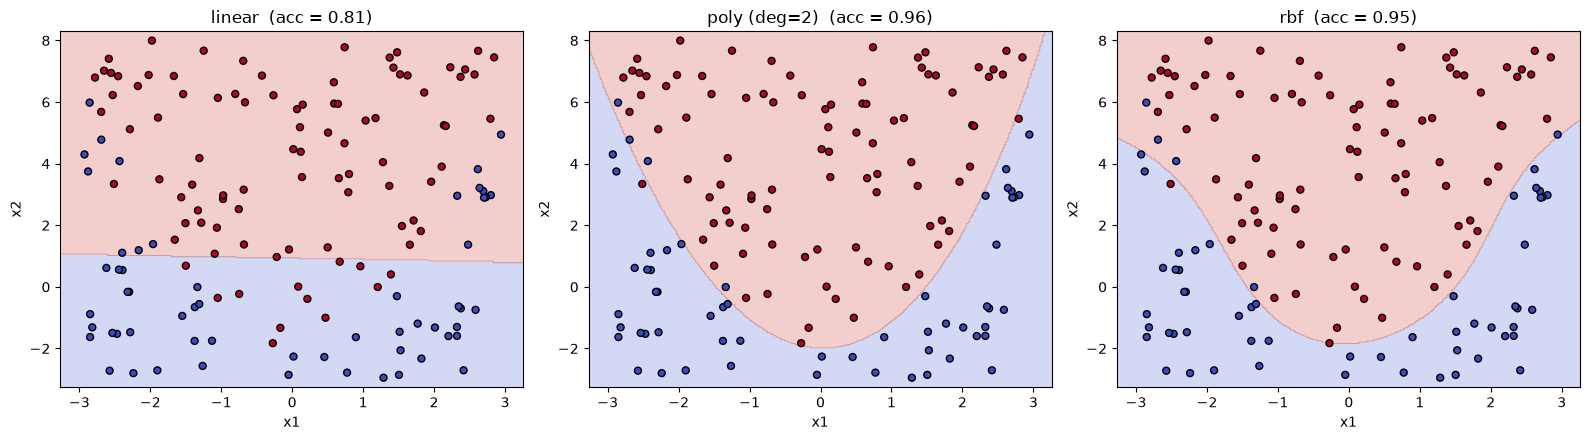

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - .3, X[:, 0].max() + .3, 300),
                     np.linspace(X[:, 1].min() - .3, X[:, 1].max() + .3, 300))
grid = sc.transform(np.c_[xx.ravel(), yy.ravel()])

for ax, (name, m) in zip(axes, fitted.items()):
    zz = m.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap='coolwarm')
    ax.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap='coolwarm',
               edgecolor='k', s=25)
    acc = accuracy_score(y_test, m.predict(x_test_s))
    ax.set_title(f'{name}  (acc = {acc:.2f})')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
plt.tight_layout()
plt.show() 

R^2 : 0.9602
RMSE: 3.7416


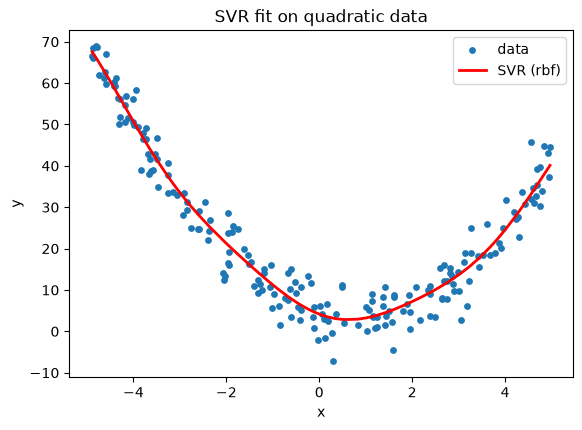

In [7]:
x_r = np.sort(rng.uniform(-5, 5, 200)).reshape(-1, 1)
y_r = 2 * x_r.ravel()**2 - 3 * x_r.ravel() + 5 + rng.normal(0, 4, 200)
xr_tr, xr_te, yr_tr, yr_te = train_test_split(x_r, y_r, test_size=0.3, random_state=5)

svr = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=100, epsilon=1))
svr.fit(xr_tr, yr_tr)
yr_pred = svr.predict(xr_te)
print('R^2 :', round(r2_score(yr_te, yr_pred), 4))
print('RMSE:', round(np.sqrt(mean_squared_error(yr_te, yr_pred)), 4))

plt.figure(figsize=(6.5, 4.5))
plt.scatter(x_r, y_r, s=15, label='data')
plt.plot(x_r, svr.predict(x_r), 'r', lw=2, label='SVR (rbf)')
plt.legend(); plt.title('SVR fit on quadratic data')
plt.xlabel('x'); plt.ylabel('y')
plt.show() 